# C2 · Taller 2 — K-Means: los tipos de día de Shiro Twin

**Aprendizaje de Máquina · Universidad Sergio Arboleda · Semestre 26-2**
Grupo Shiro — Jose Leonardo Diazgranados, Sofía Londoño, Andrés Felipe Céspedes Rondón, Alex Duran
Docente: Hernán Darío Cruz Bueno · Sector: Energía y Medio Ambiente / IoT

---

## Qué componente de Shiro construye este taller

El agente de refuerzo de Shiro Twin decide cada 10 minutos qué hacer con la casa, y decide sobre un
**estado**. La propuesta del proyecto ya anunciaba que los perfiles de rutina «alimentan al agente
como variables de estado», pero esa variable todavía no existe. Este taller la construye.

Tres decisiones de arquitectura dependen del resultado:

| Decisión del MDP | Qué la resuelve en este cuaderno |
|---|---|
| ¿Cuántos tipos de día tiene el estado? Cada tipo multiplica el tamaño de la tabla Q | La elección de *k* (§2), con las métricas del enunciado y un criterio propio de Shiro |
| ¿Hace falta un modelo, o basta con el calendario (`es_fin_semana`)? | La caracterización (§4): ¿los tipos coinciden con el calendario? |
| ¿En qué momento del día puede el agente saber qué tipo de día está viviendo? | La observabilidad (§7) — una pregunta que el enunciado no hace y que el MDP no puede esquivar |

## La decisión previa: se agrupan **días**, no lecturas

El enunciado pide aplicar K-Means «sobre su contexto». Hay dos lecturas posibles, y solo una le
sirve a Shiro:

| | **Días** (elegida) | Lecturas de 10 minutos |
|---|---|---|
| Qué se agrupa | 136 días completos, cada uno como su curva de 24 h | 19.735 lecturas × 29 variables |
| Qué produce | Tipos de día → variable de estado del MDP | Regímenes de hora y temperatura, que el árbol del Taller 2 ya encontró (`hora ≤ 7,5`) |
| Índice de Dunn con la función de la clase | Matriz 136 × 136 | Matriz de **3,1 GB** — no cabe cómodamente en memoria |

## Metodología heredada

Se mantienen las convenciones del proyecto: semilla `random_state=42`, y **siempre dos
particiones** — aquí, además del análisis sobre los 136 días, un control temporal que ajusta con los
110 días hasta el 30 de abril y asigna los 26 de mayo (§6).

---
## 1. De 19.735 lecturas a 136 días

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, pairwise_distances, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")

RS = 42
FIG = Path("figuras"); FIG.mkdir(exist_ok=True)
pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .3, "savefig.bbox": "tight"})

# Paleta del proyecto: azul = día normal, naranja = día de carga alta, verde = tercer tipo
COL = {0: "#1a73e8", 1: "#e8710a", 2: "#188038", "gris": "#5f6368", "rojo": "#d93025"}

In [2]:
CSV = "../../data set/energydata_complete.csv"      # ajustar si el cuaderno se mueve de carpeta
df = pd.read_csv(CSV, parse_dates=["date"])
df["dia"] = df["date"].dt.normalize()
df["hora"] = df["date"].dt.hour

lecturas = df.groupby("dia").size()
print(f"Días de calendario: {len(lecturas)} · completos (144 lecturas): {(lecturas == 144).sum()}")
print("Incompletos (se descartan):", {str(k.date()): int(v) for k, v in lecturas[lecturas != 144].items()})

d = df[df["dia"].isin(lecturas[lecturas == 144].index)].copy()

# Matriz día × hora: consumo medio de cada hora, en Wh
NIVEL = d.groupby(["dia", "hora"])["Appliances"].mean().unstack()
NIVEL.columns = [f"h{h:02d}" for h in NIVEL.columns]
# Misma curva dividida por el total del día: aísla la FORMA del NIVEL
FORMA = NIVEL.div(NIVEL.sum(axis=1), axis=0)

# Variables del día que NO entran al clustering: sirven para caracterizar después
info = pd.DataFrame(index=NIVEL.index)
info["fin_de_semana"] = (info.index.dayofweek >= 5).astype(int)
info["dia_semana"] = info.index.dayofweek
info["mes"] = info.index.month
info["kwh_dia"] = d.groupby("dia")["Appliances"].sum() / 1000
info["T_out"] = d.groupby("dia")["T_out"].mean()
info["T_interior"] = d.groupby("dia")[[f"T{i}" for i in range(1, 10)]].mean().mean(axis=1)
info["lights_Wh"] = d.groupby("dia")["lights"].sum()
info["hora_pico"] = NIVEL.values.argmax(axis=1)
info["entrenamiento"] = (info.index <= "2016-04-30").astype(int)

print(f"\nMatriz de clustering: {NIVEL.shape[0]} días × {NIVEL.shape[1]} horas")
print(f"Entrenamiento (hasta 30-abr): {info['entrenamiento'].sum()} días · mayo: {(1 - info['entrenamiento']).sum()} días")
print(f"Fines de semana: {info['fin_de_semana'].sum()} de {len(info)}")

Días de calendario: 138 · completos (144 lecturas): 136
Incompletos (se descartan): {'2016-01-11': 42, '2016-05-27': 109}

Matriz de clustering: 136 días × 24 horas
Entrenamiento (hasta 30-abr): 110 días · mayo: 26 días
Fines de semana: 38 de 136


### Una desviación deliberada de la diapositiva 57: no se estandariza por columna

El material de clase recomienda `StandardScaler` antes de K-Means. Esa receta existe para variables
en **unidades distintas** (precio en dólares frente a peso en kilos). Aquí las 24 columnas están
todas en Wh. Estandarizarlas daría a cada hora el mismo peso, y las horas no pesan lo mismo:

In [3]:
var_h = NIVEL.var()
print(f"Varianza del consumo por hora: mínima {var_h.min():.0f} ({var_h.idxmin()}) · máxima {var_h.max():,.0f} ({var_h.idxmax()})")
print(f"Razón: {var_h.max() / var_h.min():.0f} veces → estandarizar amplificaría el ruido de "
      f"{var_h.idxmin()} unas {np.sqrt(var_h.max() / var_h.min()):.0f} veces en desviación típica")

# ¿Qué habría pasado siguiendo la receta?
X_std = StandardScaler().fit_transform(NIVEL)
lab_crudo = KMeans(n_clusters=2, n_init=10, random_state=RS).fit_predict(NIVEL.values)
lab_std = KMeans(n_clusters=2, n_init=10, random_state=RS).fit_predict(X_std)
print(f"\nk=2 sin estandarizar → silueta {silhouette_score(NIVEL.values, lab_crudo):.3f}")
print(f"k=2 estandarizado    → silueta {silhouette_score(X_std, lab_std):.3f} · "
      f"coincidencia con la versión sin estandarizar (ARI): {adjusted_rand_score(lab_crudo, lab_std):.3f}")

Varianza del consumo por hora: mínima 50 (h04) · máxima 12,477 (h11)
Razón: 248 veces → estandarizar amplificaría el ruido de h04 unas 16 veces en desviación típica



k=2 sin estandarizar → silueta 0.392
k=2 estandarizado    → silueta 0.259 · coincidencia con la versión sin estandarizar (ARI): 1.000


**El resultado matiza el argumento, y conviene decirlo tal cual.** Con k = 2 la receta de la
diapositiva no cambia los grupos: la partición es **idéntica** (ARI = 1,000). El tipo de día es
robusto al escalado, que es una buena noticia. Lo que sí cambia es la **métrica**: la silueta baja de
0,392 a 0,259, porque el espacio estandarizado suma dimensiones de puro ruido nocturno que hacen
parecer menos separados unos grupos que son los mismos. Como el k se elige mirando métricas,
estandarizar no habría cambiado los grupos pero sí habría debilitado la evidencia para elegirlos.
Se trabaja en Wh.

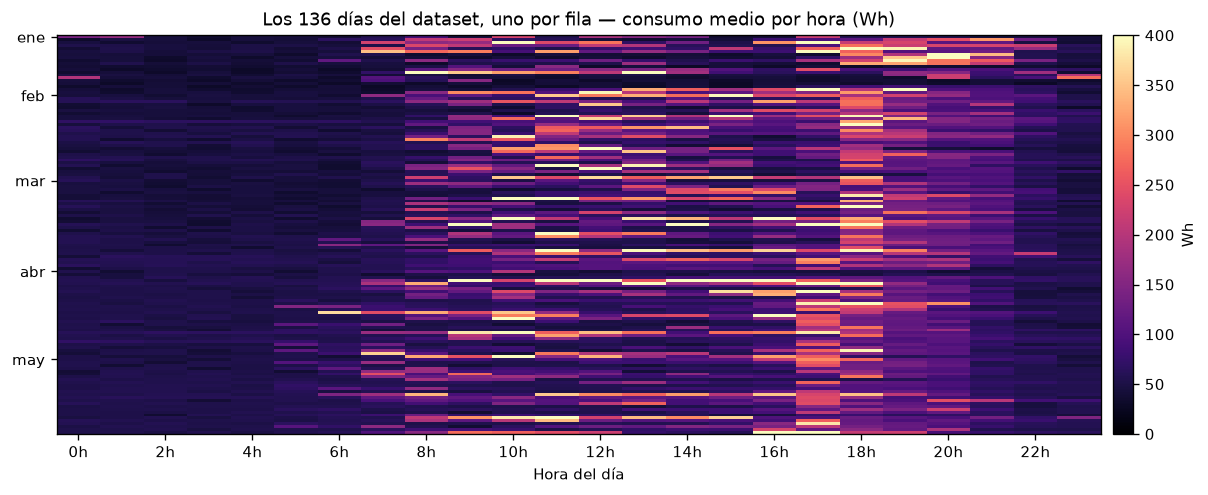

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.2))
im = ax.imshow(NIVEL.values, aspect="auto", cmap="magma", vmin=0, vmax=400, interpolation="nearest")
ax.set_xticks(range(0, 24, 2), [f"{h}h" for h in range(0, 24, 2)])
meses = pd.Series(NIVEL.index.month)
ticks = [meses[meses == m].index[0] for m in meses.unique()]
ax.set_yticks(ticks, ["ene", "feb", "mar", "abr", "may"])
ax.grid(False)
ax.set(xlabel="Hora del día", title="Los 136 días del dataset, uno por fila — consumo medio por hora (Wh)")
fig.colorbar(im, ax=ax, label="Wh", pad=.01)
plt.tight_layout(); plt.savefig(FIG / "K1_mapa_dias.png"); plt.show()

**Qué se ve antes de agrupar nada.** Las madrugadas (0–6 h) son una franja oscura casi uniforme en
los 136 días: la casa dormida consume igual todos los días. Toda la variación está entre las 7 y las
22 h, y no se reparte de forma pareja. La franja de las 17–19 h se enciende en casi todos los días;
lo que distingue a algunos es que además se encienden **durante todo el día**, con bandas brillantes
desde la mañana hasta la tarde. No se ve un patrón evidente por mes. Esa es la estructura que
K-Means tiene que formalizar.

---
## 2. Punto 1 — K-Means para k entre 2 y 10: codo, silueta y Dunn

Se aplican las tres métricas del enunciado a las dos versiones de la curva. El índice de Dunn usa
**la misma función que se presentó en clase**, sin modificarla.

In [5]:
def dunn_index(X, labels):                          # función de la clase, sin cambios
    distances = pairwise_distances(X)
    unique_clusters = np.unique(labels)
    min_intercluster = np.inf
    max_intracluster = 0
    for i in unique_clusters:
        indices_i = np.where(labels == i)[0]
        if len(indices_i) > 1:
            intra_dists = distances[np.ix_(indices_i, indices_i)]
            max_intra = np.max(intra_dists)
            max_intracluster = max(max_intracluster, max_intra)
        for j in unique_clusters:
            if i != j:
                indices_j = np.where(labels == j)[0]
                inter_dists = distances[np.ix_(indices_i, indices_j)]
                min_inter = np.min(inter_dists)
                min_intercluster = min(min_intercluster, min_inter)
    if max_intracluster == 0:
        return 0
    return min_intercluster / max_intracluster


def barrido(X):
    filas = []
    for k in range(1, 11):
        km = KMeans(n_clusters=k, n_init=10, random_state=RS).fit(X)
        f = {"k": k, "inercia": km.inertia_}
        if k >= 2:
            f["silueta"] = silhouette_score(X, km.labels_)
            f["dunn"] = dunn_index(X, km.labels_)
            f["tamaños"] = sorted(np.bincount(km.labels_).tolist(), reverse=True)
        filas.append(f)
    return pd.DataFrame(filas).set_index("k")

met_nivel = barrido(NIVEL.values)
met_forma = barrido(FORMA.values)
print("NIVEL (Wh)");            print(met_nivel.round(4).to_string())
print("\nFORMA (curva / total)"); print(met_forma.round(4).to_string())

NIVEL (Wh)
         inercia  silueta    dunn                             tamaños
k                                                                    
1   1.627206e+07      NaN     NaN                                 NaN
2   1.175508e+07   0.3922  0.2598                           [108, 28]
3   1.074408e+07   0.2253  0.1790                        [85, 31, 20]
4   9.795395e+06   0.1374  0.1187                    [55, 41, 22, 18]
5   9.143639e+06   0.1483  0.1157                 [55, 30, 28, 14, 9]
6   8.793525e+06   0.1050  0.0786             [48, 31, 23, 16, 10, 8]
7   8.174634e+06   0.1135  0.0869         [35, 34, 24, 17, 10, 10, 6]
8   7.866703e+06   0.1293  0.0968       [45, 24, 19, 17, 11, 7, 7, 6]
9   7.641391e+06   0.1631  0.1529      [55, 27, 22, 8, 7, 7, 4, 3, 3]
10  7.181393e+06   0.1205  0.1046  [36, 30, 20, 20, 7, 7, 6, 4, 3, 3]

FORMA (curva / total)
    inercia  silueta    dunn                                tamaños
k                                                         

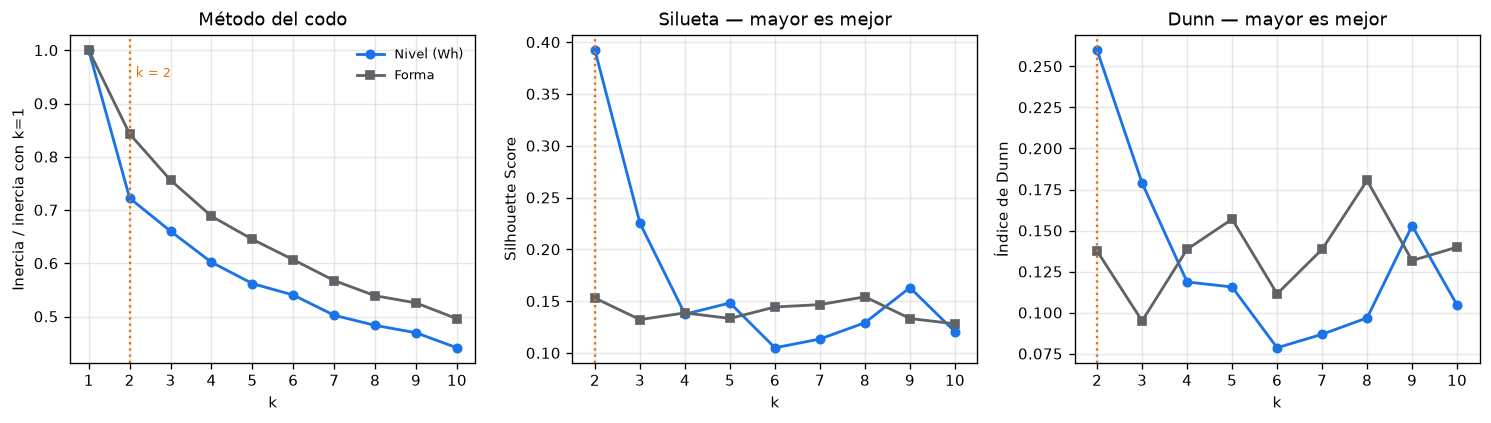

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.6))
for tabla, nombre, c, mk in [(met_nivel, "Nivel (Wh)", COL[0], "o"), (met_forma, "Forma", COL["gris"], "s")]:
    ax[0].plot(tabla.index, tabla["inercia"] / tabla.loc[1, "inercia"], mk + "-", color=c, label=nombre, lw=1.7, ms=5)
    ax[1].plot(tabla.index[1:], tabla["silueta"].iloc[1:], mk + "-", color=c, label=nombre, lw=1.7, ms=5)
    ax[2].plot(tabla.index[1:], tabla["dunn"].iloc[1:], mk + "-", color=c, label=nombre, lw=1.7, ms=5)
for a in ax:
    a.axvline(2, color=COL[1], ls=":", lw=1.4)
    a.set_xticks(range(1, 11)); a.set_xlabel("k")
ax[0].set(ylabel="Inercia / inercia con k=1", title="Método del codo")
ax[1].set(ylabel="Silhouette Score", title="Silueta — mayor es mejor", xlim=(1.5, 10.5))
ax[2].set(ylabel="Índice de Dunn", title="Dunn — mayor es mejor", xlim=(1.5, 10.5))
ax[0].legend(frameon=False, fontsize=8)
ax[0].text(2.15, .95, "k = 2", color=COL[1], fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "K2_metricas.png"); plt.show()

### El k elegido: **2** — y esta vez las tres métricas están de acuerdo

En el ejemplo de clase las métricas se contradecían (silueta y Dunn señalaban k = 2 y el codo,
k = 4–5), y la elección fue un compromiso. Aquí, sobre la curva en Wh, **coinciden las tres**:

| Métrica | Qué dice | Evidencia |
|---|---|---|
| Codo | k = 2 | Pasar de 1 a 2 clústers reduce la inercia un **28 %**; cada clúster adicional, menos de un 9 % |
| Silueta | k = 2 | **0,392**, y cae a 0,225 con k = 3 y a 0,137 con k = 4 |
| Dunn | k = 2 | **0,260**, el máximo de todo el barrido |

La versión de **forma** no tiene estructura que elegir: la silueta se queda entre 0,13 y 0,15 para
todos los k, y Dunn oscila sin un máximo claro. Se conserva solo como contraste (§4.4).

**Criterio propio de Shiro.** Cada tipo de día multiplica la tabla Q del agente: con 24 horas × k
tipos × bandas de temperatura × acciones, k = 2 frente a k = 8 es la diferencia entre un agente que
visita cada estado muchas veces y uno que no llega a visitarlos. Aquí no hay tensión: el k que
prefieren las métricas es también el más barato para el espacio de estados. En §7 se añade un
tercer argumento — cuándo se puede *observar* el tipo de día — que también favorece k = 2.

---
## 3. Punto 2 — Visualización en 2D: PCA y t-SNE

Como en el material de clase, se colorea la misma proyección con k = 2, 3 y 4, para ver qué agrega
cada clúster adicional. Los clústers se calculan siempre en el espacio original de 24 horas; la
proyección solo sirve para mirar.

Varianza explicada: PC1 37.2 % · PC2 12.9 % · juntas 50.1 %


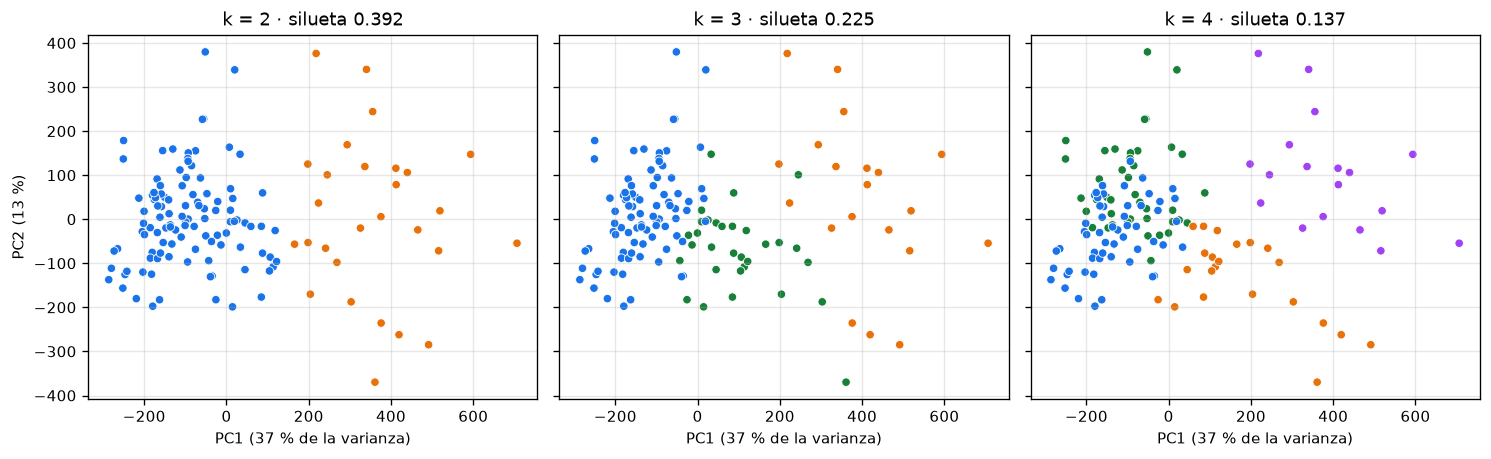

In [7]:
def ordenar(labels, X):
    # Renumera los clústers por consumo total del centroide: 0 = el de menor consumo
    tot = np.array([X[labels == c].sum(axis=1).mean() for c in np.unique(labels)])
    mapa = {old: new for new, old in enumerate(np.argsort(tot))}
    return np.vectorize(mapa.get)(labels)

X = NIVEL.values
LAB = {k: ordenar(KMeans(n_clusters=k, n_init=10, random_state=RS).fit_predict(X), X) for k in (2, 3, 4)}
COLS4 = [COL[0], COL[2], COL[1], "#a142f4"]

pca = PCA(n_components=2).fit(X)
P = pca.transform(X)
ev = pca.explained_variance_ratio_
print(f"Varianza explicada: PC1 {ev[0]*100:.1f} % · PC2 {ev[1]*100:.1f} % · juntas {ev.sum()*100:.1f} %")

def colores(lab, k):
    paleta = {2: [COL[0], COL[1]], 3: [COL[0], COL[2], COL[1]], 4: COLS4}[k]
    return [paleta[i] for i in lab]

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.9), sharex=True, sharey=True)
for a, k in zip(ax, (2, 3, 4)):
    a.scatter(P[:, 0], P[:, 1], c=colores(LAB[k], k), s=26, edgecolors="white", linewidths=.5)
    s = silhouette_score(X, LAB[k])
    a.set(title=f"k = {k} · silueta {s:.3f}", xlabel=f"PC1 ({ev[0]*100:.0f} % de la varianza)")
ax[0].set_ylabel(f"PC2 ({ev[1]*100:.0f} %)")
plt.tight_layout(); plt.savefig(FIG / "K3_pca.png"); plt.show()

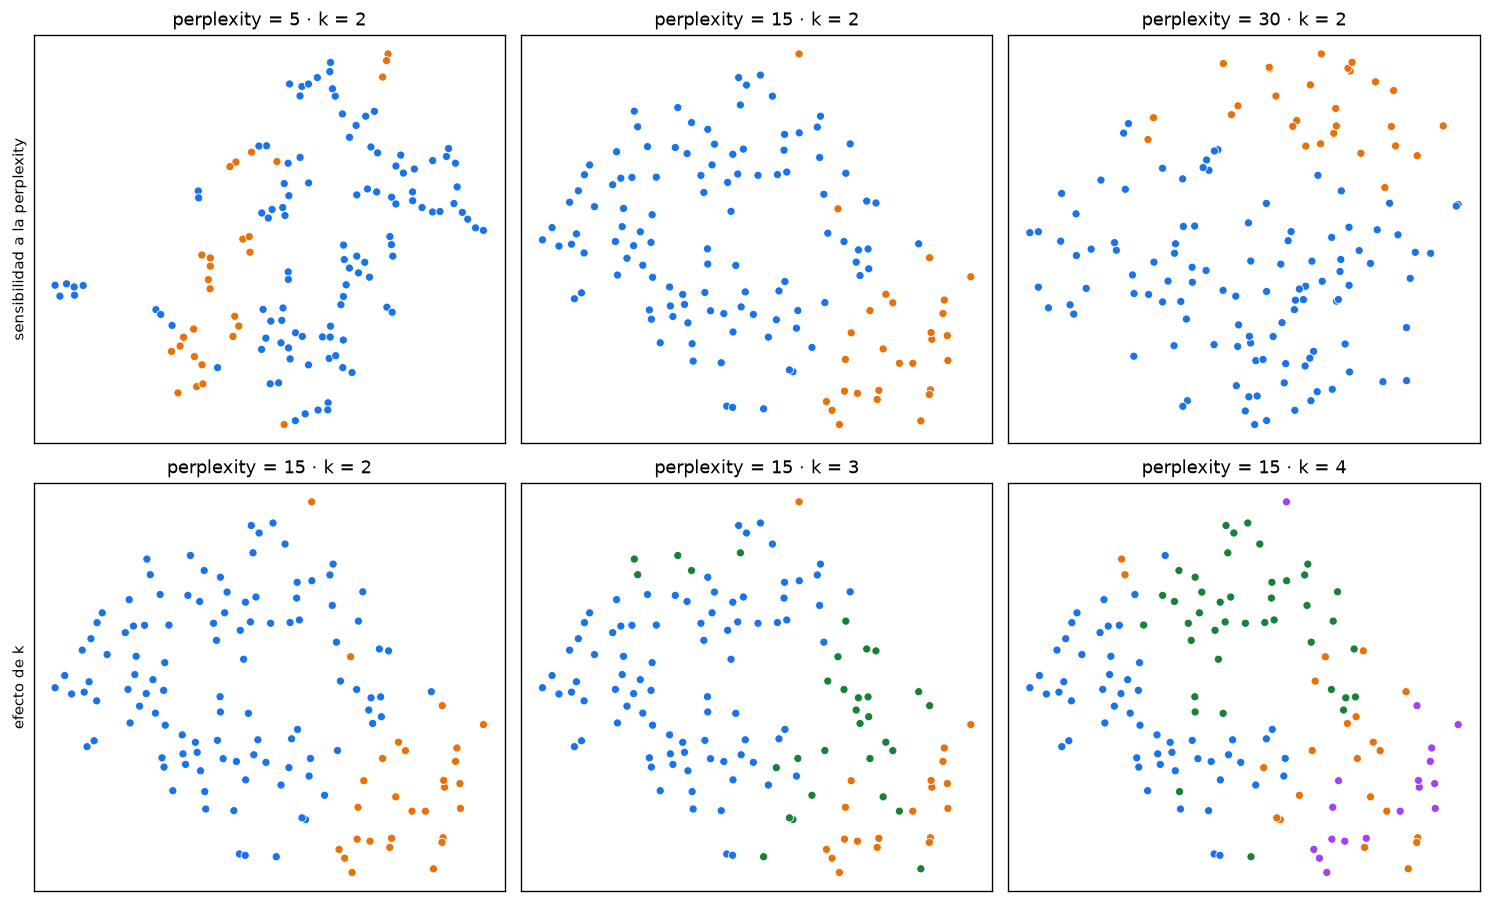

In [8]:
# t-SNE: la clase recomienda perplexity entre 5 y 50 y learning_rate ≈ 200.
# Con 136 puntos se prueban 5, 15 y 30 para no depender de un único valor.
TS = {p: TSNE(n_components=2, perplexity=p, learning_rate=200, init="pca",
              random_state=RS).fit_transform(X) for p in (5, 15, 30)}

fig, ax = plt.subplots(2, 3, figsize=(12.5, 7.6))
for a, p in zip(ax[0], (5, 15, 30)):
    a.scatter(TS[p][:, 0], TS[p][:, 1], c=colores(LAB[2], 2), s=24, edgecolors="white", linewidths=.5)
    a.set(title=f"perplexity = {p} · k = 2", xticks=[], yticks=[])
for a, k in zip(ax[1], (2, 3, 4)):
    a.scatter(TS[15][:, 0], TS[15][:, 1], c=colores(LAB[k], k), s=24, edgecolors="white", linewidths=.5)
    a.set(title=f"perplexity = 15 · k = {k}", xticks=[], yticks=[])
ax[0, 0].set_ylabel("sensibilidad a la perplexity"); ax[1, 0].set_ylabel("efecto de k")
plt.tight_layout(); plt.savefig(FIG / "K4_tsne.png"); plt.show()

### ¿Cuál separa mejor los grupos?

**PCA separa mejor, y la razón es informativa.** Los dos primeros componentes retienen la mitad de la
varianza (37 % + 13 %), y con k = 2 los días de carga alta se ordenan casi por completo a lo largo de
PC1: la diferencia entre los dos tipos es, sobre todo, *cuánto* se consume de día — una dirección
lineal, que es justo lo que PCA captura. Con k = 3 y k = 4 los clústers nuevos aparecen como cortes
dentro de la nube principal, sin un espacio vacío que los separe: por eso la silueta cae.

**t-SNE no muestra grupos que PCA no muestre.** Con perplexity 5 la nube se rompe en hebras cortas:
los días de carga alta quedan juntos localmente, pero repartidos en varios fragmentos, así que el
gráfico sugiere más grupos de los que hay. Con 15 y 30 aparece una sola nube, con los días de carga
alta agrupados en un borde — la misma lectura que da PCA, con menos nitidez. Como advierte la
diapositiva 76, en t-SNE las distancias entre grupos no tienen significado absoluto: aquí no revela
estructura oculta porque la estructura principal es lineal. Cuando el patrón es una diferencia de
intensidad y no una forma curva, PCA basta.

---
## 4. Punto 3 — Caracterización de los clústers

Se agrupó **solo** con la curva de consumo. Ahora se caracteriza con variables que no entraron al
modelo — el calendario, el clima, la iluminación —, de modo que cualquier diferencia que aparezca es
un hallazgo y no una consecuencia de cómo se construyeron los grupos.

### 4.1 Los dos tipos de día

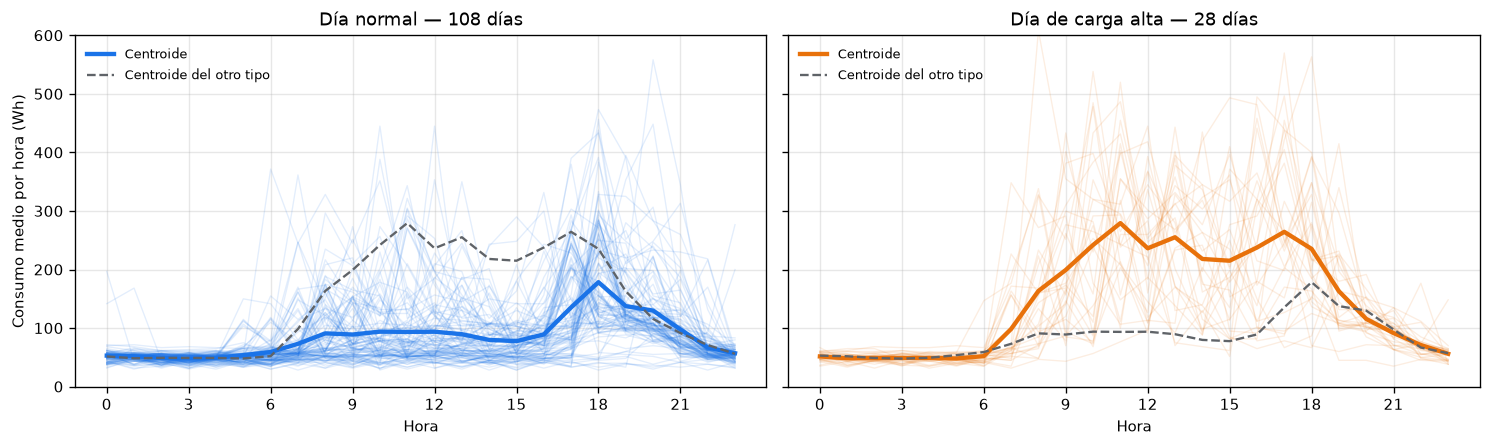

Consumo medio del centroide por franja (Wh):
               Día normal  Día de carga alta
Madrugada 0-6        50.9               49.3
Mañana 6-12          83.3              172.5
Tarde 12-18          94.3              237.8
Noche 18-24         111.3              122.2


In [9]:
lab2 = LAB[2]
nombres = {0: "Día normal", 1: "Día de carga alta"}

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8), sharey=True)
horas = np.arange(24)
for c in (0, 1):
    for fila in X[lab2 == c]:
        ax[c].plot(horas, fila, color=COL[c], alpha=.12, lw=.8)
    ax[c].plot(horas, X[lab2 == c].mean(axis=0), color=COL[c], lw=2.6, label="Centroide")
    ax[c].plot(horas, X[lab2 == 1 - c].mean(axis=0), color=COL["gris"], lw=1.4, ls="--",
               label="Centroide del otro tipo")
    ax[c].set(title=f"{nombres[c]} — {(lab2 == c).sum()} días", xlabel="Hora", xticks=range(0, 24, 3), ylim=(0, 600))
    ax[c].legend(frameon=False, fontsize=8, loc="upper left")
ax[0].set_ylabel("Consumo medio por hora (Wh)")
plt.tight_layout(); plt.savefig(FIG / "K5_perfiles.png"); plt.show()

cen = pd.DataFrame({nombres[c]: X[lab2 == c].mean(axis=0) for c in (0, 1)}, index=horas)
print("Consumo medio del centroide por franja (Wh):")
franjas = {"Madrugada 0-6": range(0, 6), "Mañana 6-12": range(6, 12),
           "Tarde 12-18": range(12, 18), "Noche 18-24": range(18, 24)}
print(pd.DataFrame({f: cen.loc[list(h)].mean() for f, h in franjas.items()}).T.round(1).to_string())

In [10]:
tabla = info.assign(tipo=[nombres[c] for c in lab2]).groupby("tipo").agg(
    dias=("kwh_dia", "size"),
    kwh_dia=("kwh_dia", "mean"),
    hora_pico=("hora_pico", lambda s: s.mode().iat[0]),
    pct_fin_de_semana=("fin_de_semana", lambda s: s.mean() * 100),
    T_exterior=("T_out", "mean"),
    T_interior=("T_interior", "mean"),
    lights_Wh_dia=("lights_Wh", "mean"),
).round(2)
print("TABLA RESUMEN — medias por clúster (k = 2)")
print(tabla.T.to_string())

def cramer(a, b):
    ct = pd.crosstab(a, b).values
    chi2, p, _, _ = chi2_contingency(ct)
    return np.sqrt(chi2 / (ct.sum() * (min(ct.shape) - 1))), p

for var, et in [("fin_de_semana", "fin de semana"), ("dia_semana", "día de la semana"), ("mes", "mes")]:
    v, p = cramer(lab2, info[var])
    print(f"\nAsociación con {et:17s}: V de Cramér = {v:.3f} (p = {p:.3f})")

print("\nDías de carga alta por día de la semana:")
ds = pd.crosstab(lab2, info["dia_semana"]); ds.columns = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
ds.index = [nombres[i] for i in ds.index]; print(ds.to_string())

TABLA RESUMEN — medias por clúster (k = 2)
tipo               Día de carga alta  Día normal
dias                           28.00      108.00
kwh_dia                        20.94       12.23
hora_pico                      11.00       18.00
pct_fin_de_semana              28.57       27.78
T_exterior                      7.31        7.37
T_interior                     19.34       19.37
lights_Wh_dia                 696.79      501.76

Asociación con fin de semana    : V de Cramér = 0.000 (p = 1.000)

Asociación con día de la semana : V de Cramér = 0.246 (p = 0.221)

Asociación con mes              : V de Cramér = 0.134 (p = 0.655)

Días de carga alta por día de la semana:
                   lun  mar  mié  jue  vie  sáb  dom
Día normal          12   18   18   17   13   14   16
Día de carga alta    7    2    2    3    6    5    3


Variables ordenadas por cuánto diferencian el día de carga alta del normal (|d| > 0,8 = efecto grande):
Consumo Tarde 12-18    3.76
Consumo Mañana 6-12    2.30
RH_3                   0.47
RH_9                   0.46
lights                 0.44
RH_1                   0.40
Windspeed              0.39
RH_8                   0.38
RH_4                   0.38
RH_5                   0.37
RH_2                   0.30
RH_7                   0.29


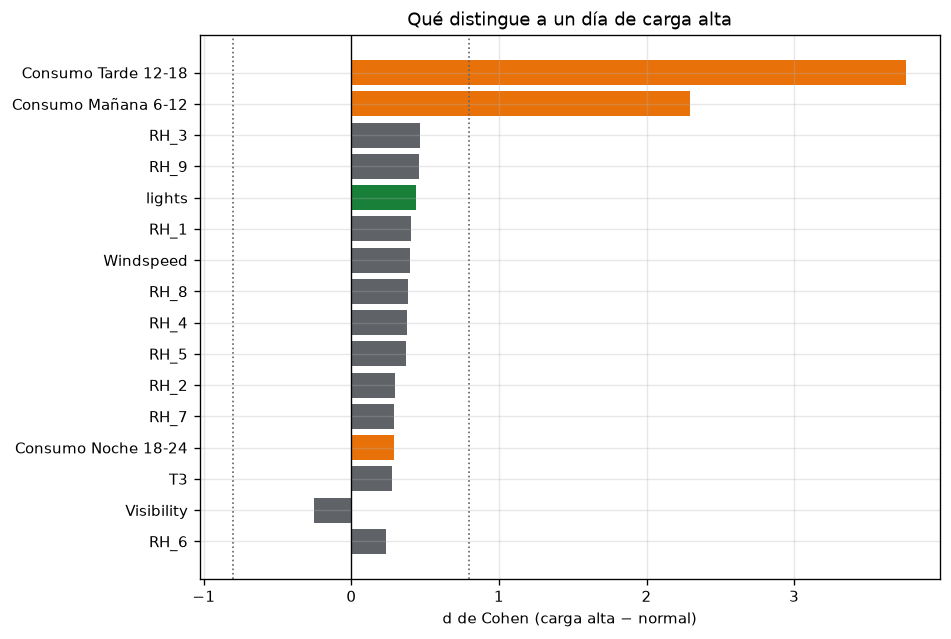

In [11]:
# ¿Qué variables diferencian los clústers? Tamaño del efecto (d de Cohen) sobre medias diarias
diarias = d.groupby("dia")[["lights", "T_out", "RH_out", "Press_mm_hg", "Windspeed", "Visibility",
                            "Tdewpoint"] + [f"T{i}" for i in range(1, 10)] + [f"RH_{i}" for i in range(1, 10)]].mean()
for f, h in franjas.items():
    diarias[f"Consumo {f}"] = NIVEL.iloc[:, list(h)].mean(axis=1).values

def cohen_d(v, lab):
    a, b = v[lab == 1], v[lab == 0]
    s = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / s

efecto = pd.Series({c: cohen_d(diarias[c].values, lab2) for c in diarias.columns}).sort_values(key=abs, ascending=False)
print("Variables ordenadas por cuánto diferencian el día de carga alta del normal (|d| > 0,8 = efecto grande):")
print(efecto.round(2).head(12).to_string())

fig, ax = plt.subplots(figsize=(8, 5.4))
top = efecto.head(16)[::-1]
col_barras = [COL[1] if n.startswith("Consumo") else (COL[2] if n == "lights" else COL["gris"]) for n in top.index]
ax.barh(range(len(top)), top.values, color=col_barras)
ax.set_yticks(range(len(top)), top.index)
ax.axvline(0, color="k", lw=.8)
for x in (-.8, .8):
    ax.axvline(x, color=COL["gris"], ls=":", lw=1)
ax.set(xlabel="d de Cohen (carga alta − normal)", title="Qué distingue a un día de carga alta")
plt.tight_layout(); plt.savefig(FIG / "K9_variables.png"); plt.show()

In [12]:
# Una regla legible: un árbol de profundidad 2 que intenta reproducir el clúster a partir de las horas
arbol = DecisionTreeClassifier(max_depth=2, random_state=RS).fit(NIVEL, lab2)
print(export_text(arbol, feature_names=list(NIVEL.columns), decimals=0))
print(f"La regla reproduce el clúster en el {arbol.score(NIVEL, lab2) * 100:.1f} % de los días")

|--- h13 <= 199
|   |--- h17 <= 398
|   |   |--- class: 0
|   |--- h17 >  398
|   |   |--- class: 1
|--- h13 >  199
|   |--- h15 <= 73
|   |   |--- class: 0
|   |--- h15 >  73
|   |   |--- class: 1

La regla reproduce el clúster en el 96.3 % de los días


### Lectura de la caracterización

**Los dos tipos se separan de día, no de noche.** Las madrugadas son idénticas (51 frente a 49 Wh) y
las noches casi (111 frente a 122 Wh). La diferencia es un **bloque diurno de 8 a 18 h**: por la
mañana el día de carga alta consume el doble (172 frente a 83 Wh) y por la tarde, dos veces y media
(238 frente a 94 Wh). Su curva tiene dos jorobas —a las 11 y a las 17 h—, mientras que el día normal
solo tiene el pico de las 18 h. El árbol de profundidad 2 lo resume en una regla que mira sobre todo
la 1 de la tarde (`h13 > 199 Wh`) y reproduce el clúster en el 96,3 % de los días: el tipo de día es,
en la práctica, «¿hubo un bloque de consumo fuerte alrededor del mediodía?».

**El calendario no los explica.** La proporción de fines de semana es la misma en los dos tipos
(28 % y 29 %) y la asociación es nula (V de Cramér = 0,000). El mes tampoco es significativo. Hay más
lunes y viernes entre los días de carga alta, pero con 28 días esa diferencia no alcanza
significación (p = 0,22).

**El clima tampoco; la actividad de la casa, sí.** Fuera del propio consumo, ninguna variable tiene
un efecto grande: todas quedan por debajo de |d| = 0,5. La temperatura exterior es prácticamente la
misma (7,3 frente a 7,4 °C). Lo que se mueve, con efecto pequeño pero en la misma dirección, son las
variables de actividad doméstica: `lights` (+39 %) y las humedades interiores, con la de la
**lavandería (RH_3)** a la cabeza y la de la cocina (RH_1) también arriba — coherente con lavar,
secar y cocinar. Por la correlación entre habitaciones (advertencia §8 del proyecto), el orden
interno entre humedades no se lee como prueba; que suban en conjunto, sí.

**Significado real en el sector.** Un día de carga alta no es un día frío ni un fin de semana: es un
día en que las personas de la casa encienden, durante el día, aparatos de alta potencia —lavadora,
secadora, horno, lavavajillas—. Son exactamente las **cargas diferibles** del espacio de acciones
del MDP. Para Shiro, el día de carga alta es donde está el margen de ahorro: un día normal tiene poco
que mover.

### 4.2 El refinamiento con k = 3: aparece una rutina de fin de semana

In [13]:
lab3 = LAB[3]
nom3 = {0: "Día normal", 1: "Mañana activa", 2: "Carga muy alta"}
t3 = info.assign(tipo=[nom3[c] for c in lab3]).groupby("tipo").agg(
    dias=("kwh_dia", "size"), kwh_dia=("kwh_dia", "mean"),
    hora_pico=("hora_pico", lambda s: s.mode().iat[0]),
    pct_fin_de_semana=("fin_de_semana", lambda s: s.mean() * 100),
    T_exterior=("T_out", "mean"), lights_Wh_dia=("lights_Wh", "mean")).round(2)
print(t3.T.to_string())
v, p = cramer(lab3, info["fin_de_semana"])
print(f"\nk = 3 — asociación con fin de semana: V de Cramér = {v:.3f} (p = {p:.3f})")
ds3 = pd.crosstab(lab3, info["dia_semana"]); ds3.columns = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
ds3.index = [nom3[i] for i in ds3.index]; print(ds3.to_string())

tipo               Carga muy alta  Día normal  Mañana activa
dias                        20.00       85.00          31.00
kwh_dia                     21.95       11.48          15.88
hora_pico                   10.00       18.00          11.00
pct_fin_de_semana           20.00       22.35          48.39
T_exterior                   8.54        7.47           6.31
lights_Wh_dia              629.00      475.88         666.77

k = 3 — asociación con fin de semana: V de Cramér = 0.248 (p = 0.015)
                lun  mar  mié  jue  vie  sáb  dom
Día normal        9   17   18   14    8    7   12
Mañana activa     3    2    0    4    7    8    7
Carga muy alta    7    1    2    2    4    4    0


Con k = 3 el día de carga alta se divide en dos, y uno de ellos sí tiene firma de calendario: una
**mañana activa** con casi la mitad de sus días en fin de semana (48 %, frente al 28 % general),
concentrada de viernes a domingo. La asociación con el fin de semana deja de ser nula
(V de Cramér ≈ 0,25, significativa al 5 %).

Es la rutina que la propuesta esperaba encontrar («día laboral frente a fin de semana»), y es real.
Pero cuesta: la silueta cae de 0,392 a 0,225, y — como se verá en §7 — este tipo se reconoce más
tarde en el día. Se documenta como refinamiento, no se adopta como variable de estado.

### 4.3 El contraste con la forma: la hipótesis del plan no se confirmó

In [14]:
labF = ordenar(KMeans(n_clusters=2, n_init=10, random_state=RS).fit_predict(FORMA.values), X)
for nombre_v, lab_v in [("Nivel", lab2), ("Forma", labF)]:
    v1, p1 = cramer(lab_v, info["fin_de_semana"]); v2, p2 = cramer(lab_v, info["mes"])
    print(f"{nombre_v:6s} k=2 → fin de semana: V = {v1:.3f} (p={p1:.3f}) · mes: V = {v2:.3f} (p={p2:.3f})")
print(f"\nCoincidencia entre los clústers de nivel y de forma (ARI): {adjusted_rand_score(lab2, labF):.3f}")

Nivel  k=2 → fin de semana: V = 0.000 (p=1.000) · mes: V = 0.134 (p=0.655)
Forma  k=2 → fin de semana: V = 0.185 (p=0.031) · mes: V = 0.247 (p=0.080)

Coincidencia entre los clústers de nivel y de forma (ARI): 0.255


El plan partía de una hipótesis doble: agrupar por **nivel** separaría meses (por la deriva
estacional que midió el parcial) y agrupar por **forma** separaría rutinas de calendario.

- **La primera mitad quedó refutada.** El nivel no separa meses (V = 0,134, p = 0,655).
- **La segunda se cumplió solo a medias.** La forma sí se asocia con el fin de semana (V = 0,185,
  p = 0,031), pero débilmente, y sin una estructura de clústers que la sostenga: silueta ≈ 0,14 para
  todo k, y —como muestra §5— dos algoritmos que no se ponen de acuerdo sobre qué grupos son.

Lo que los datos muestran con firmeza es otra cosa: los días de esta casa se diferencian sobre todo
por **si ocurre o no un bloque de consumo fuerte durante el día**, y eso no lo decide ni el
calendario ni la estación. Se reporta tal cual: una hipótesis refutada con datos es un resultado,
no un fracaso.

---
## 5. Segunda técnica: clustering jerárquico (Ward)

El criterio de cierre del proyecto exige **al menos dos técnicas de clustering comparadas**. Con 136
puntos el jerárquico es barato y ofrece algo que K-Means no da: el árbol completo de fusiones, sin
fijar k de antemano.

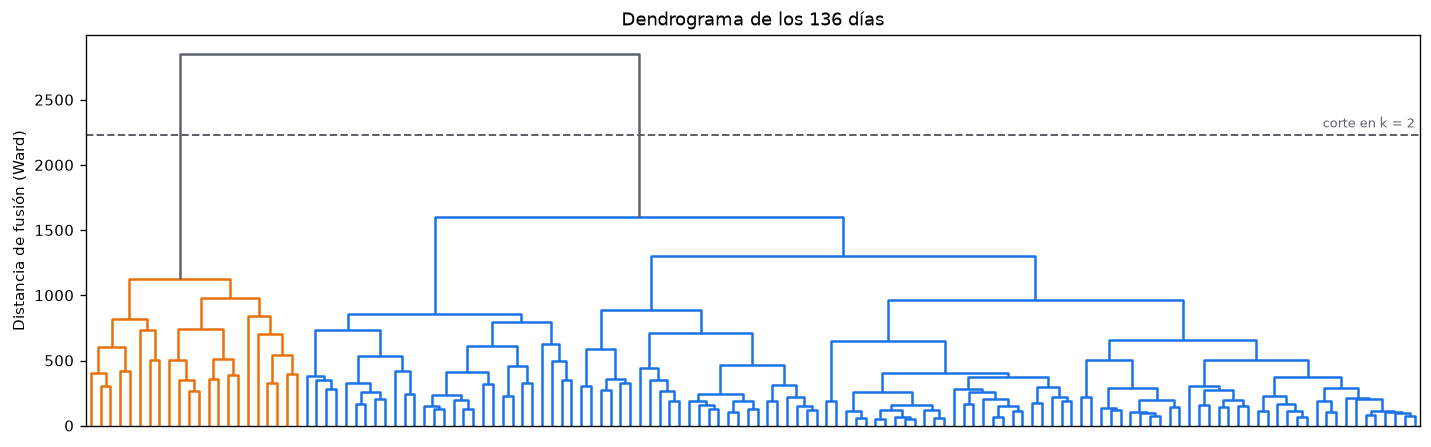

   ARI nivel (K-Means vs Ward)  silueta Ward nivel         tamaños Ward  ARI forma (K-Means vs Ward)
k                                                                                                   
2                        0.736               0.400            [114, 22]                        0.188
3                        0.796               0.200         [86, 28, 22]                        0.221
4                        0.543               0.141     [61, 28, 25, 22]                        0.372
5                        0.663               0.146  [61, 28, 25, 14, 8]                        0.377


In [15]:
from scipy.cluster.hierarchy import set_link_color_palette
Z = linkage(X, method="ward")
corte = (Z[-1, 2] + Z[-2, 2]) / 2               # entre las dos fusiones más altas → exactamente 2 grupos
set_link_color_palette([COL[1], COL[0]])
fig, ax = plt.subplots(figsize=(12, 3.8))
dendrogram(Z, no_labels=True, color_threshold=corte, above_threshold_color=COL["gris"], ax=ax)
set_link_color_palette(None)
ax.axhline(corte, color=COL["gris"], ls="--", lw=1.2)
ax.text(len(X) * 10 - 5, corte + 60, "corte en k = 2", color=COL["gris"], ha="right", fontsize=8)
ax.set(ylabel="Distancia de fusión (Ward)", title="Dendrograma de los 136 días")
ax.grid(False)
plt.tight_layout(); plt.savefig(FIG / "K6_dendrograma.png"); plt.show()

filas = []
for k in (2, 3, 4, 5):
    lk = KMeans(n_clusters=k, n_init=10, random_state=RS).fit_predict(X)
    lw = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)
    lkF = KMeans(n_clusters=k, n_init=10, random_state=RS).fit_predict(FORMA.values)
    lwF = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(FORMA.values)
    filas.append({"k": k, "ARI nivel (K-Means vs Ward)": adjusted_rand_score(lk, lw),
                  "silueta Ward nivel": silhouette_score(X, lw),
                  "tamaños Ward": sorted(np.bincount(lw).tolist(), reverse=True),
                  "ARI forma (K-Means vs Ward)": adjusted_rand_score(lkF, lwF)})
print(pd.DataFrame(filas).set_index("k").round(3).to_string())

**Las dos técnicas encuentran los mismos dos tipos.** Con k = 2 el acuerdo entre K-Means y Ward es
alto (ARI ≈ 0,74) y el dendrograma muestra la separación más alta del árbol justo en ese corte. Con
la versión de forma, en cambio, las dos técnicas no se ponen de acuerdo (ARI ≈ 0,19): la «estructura»
de la forma depende del algoritmo que se use, que es la señal de que no existe.

Para Shiro este acuerdo importa más que cualquier métrica aislada: si dos algoritmos con supuestos
distintos (centroides esféricos frente a fusiones que minimizan la varianza) recortan los mismos
grupos, el tipo de día es una propiedad de los datos y no un artefacto del método. **El criterio de
cierre «dos técnicas comparadas» queda cumplido.**

---
## 6. Control temporal: ¿mayo trae tipos de día nuevos?

La convención del proyecto exige un control fuera de muestra. Se ajusta K-Means solo con los
110 días hasta el 30 de abril y se asignan los 26 días de mayo, que el modelo nunca vio.

Distancia media al centroide más cercano: entrenamiento 282 · mayo 230
Días de mayo más lejos que el percentil 95 del entrenamiento: 0 de 26
Proporción de días de carga alta: entrenamiento 22.7 % · mayo 11.5 %


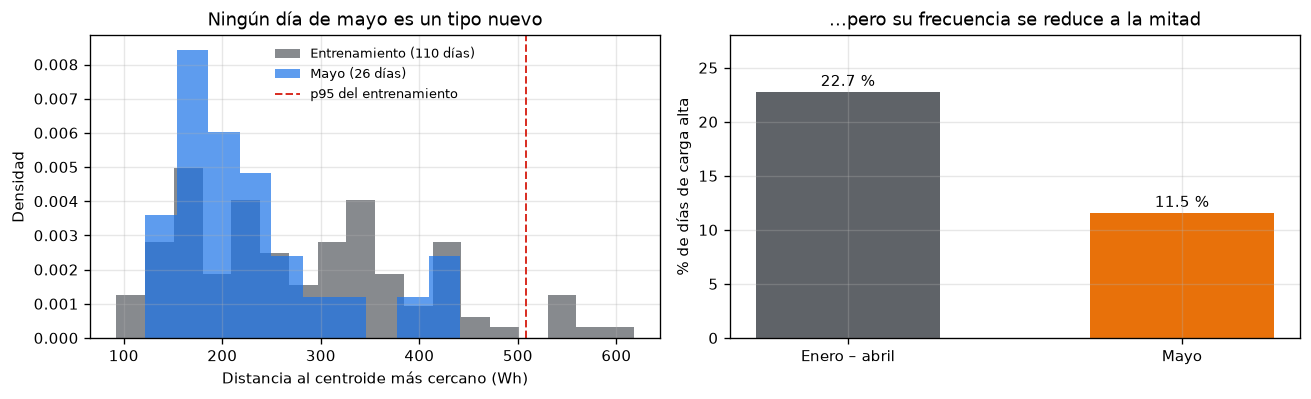

In [16]:
tr = info["entrenamiento"].values == 1
km_tr = KMeans(n_clusters=2, n_init=10, random_state=RS).fit(X[tr])
alto = int(np.argmax(km_tr.cluster_centers_.sum(axis=1)))
d_tr = km_tr.transform(X[tr]).min(axis=1)
d_my = km_tr.transform(X[~tr]).min(axis=1)
p95 = np.percentile(d_tr, 95)
frac_tr = (km_tr.labels_ == alto).mean()
frac_my = (km_tr.predict(X[~tr]) == alto).mean()

print(f"Distancia media al centroide más cercano: entrenamiento {d_tr.mean():.0f} · mayo {d_my.mean():.0f}")
print(f"Días de mayo más lejos que el percentil 95 del entrenamiento: {(d_my > p95).sum()} de {(~tr).sum()}")
print(f"Proporción de días de carga alta: entrenamiento {frac_tr*100:.1f} % · mayo {frac_my*100:.1f} %")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(d_tr, bins=18, color=COL["gris"], alpha=.75, label="Entrenamiento (110 días)", density=True)
ax[0].hist(d_my, bins=10, color=COL[0], alpha=.7, label="Mayo (26 días)", density=True)
ax[0].axvline(p95, color=COL["rojo"], ls="--", lw=1.2, label="p95 del entrenamiento")
ax[0].set(xlabel="Distancia al centroide más cercano (Wh)", ylabel="Densidad",
          title="Ningún día de mayo es un tipo nuevo")
ax[0].legend(frameon=False, fontsize=7.5)
ax[1].bar(["Enero – abril", "Mayo"], [frac_tr * 100, frac_my * 100], color=[COL["gris"], COL[1]], width=.55)
for i, v in enumerate([frac_tr * 100, frac_my * 100]):
    ax[1].text(i, v + .6, f"{v:.1f} %", ha="center", fontsize=9)
ax[1].set(ylabel="% de días de carga alta", ylim=(0, 28), title="…pero su frecuencia se reduce a la mitad")
plt.tight_layout(); plt.savefig(FIG / "K7_mayo.png"); plt.show()

**Los tipos de día no envejecen; su frecuencia sí.** Ningún día de mayo cae más lejos de su centroide
que el 95 % de los días de entrenamiento: mayo no trae rutinas desconocidas. Pero la proporción de
días de carga alta cae de 22,7 % a 11,5 %.

Es el mismo patrón que el parcial encontró en el umbral de anomalía, visto desde otro ángulo: la
**definición** se sostiene, la **frecuencia** cambia con la estación. En términos del MDP, el
espacio de estados queda bien definido, pero la probabilidad con la que el entorno produce cada tipo
de día debe recalibrarse con el tiempo, igual que el umbral.

---
## 7. La pregunta que el enunciado no hace: ¿a qué hora sabe el agente qué tipo de día es?

El tipo de día se definió con la curva **completa** de 24 horas. Pero el agente decide cada 10
minutos, en tiempo real: a las 8 de la mañana no conoce la curva de las 18 h. Una variable de estado
que solo se conoce al terminar el día no le sirve para decidir *durante* el día.

Para medirlo, a cada hora h se asigna cada día al centroide más cercano usando solo las horas
0 … h, y se compara con su asignación usando el día completo.

Línea base (decir siempre «día normal»): 79.4 %
            k=2                           k=3                      
        acierto carga_alta_reconocida acierto carga_alta_reconocida
hasta_h                                                            
0          43.4                  46.4    36.0                   5.0
6          55.9                  67.9    36.0                  40.0
8          72.1                  50.0    59.6                  50.0
9          80.9                  60.7    70.6                  60.0
10         86.0                  67.9    72.8                  60.0
11         89.0                  82.1    83.8                  60.0
12         90.4                  89.3    84.6                  55.0
14         93.4                  92.9    89.0                  75.0
17         99.3                 100.0    97.8                 100.0

Con k = 2, la asignación supera la línea base cuando el día se ha observado hasta las 9 h (es decir, desde las 10:00)


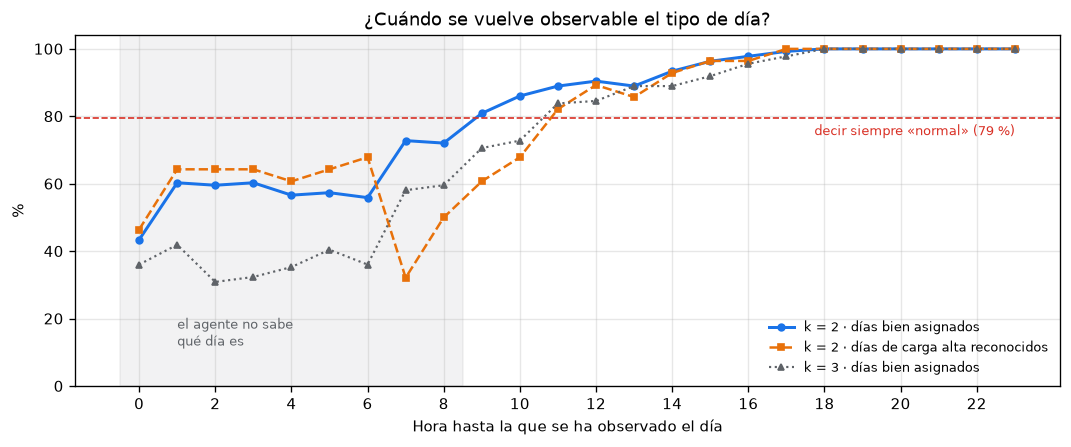

In [17]:
def observabilidad(X, labels, centros, alto):
    filas = []
    for h in range(24):
        dist = ((X[:, None, :h + 1] - centros[None, :, :h + 1]) ** 2).sum(axis=2)
        parcial = dist.argmin(axis=1)
        filas.append({"hasta_h": h, "acierto": (parcial == labels).mean() * 100,
                      "carga_alta_reconocida": (parcial[labels == alto] == alto).mean() * 100})
    return pd.DataFrame(filas).set_index("hasta_h")

cen2 = np.vstack([X[lab2 == c].mean(axis=0) for c in (0, 1)])
cen3 = np.vstack([X[lab3 == c].mean(axis=0) for c in (0, 1, 2)])
obs2 = observabilidad(X, lab2, cen2, 1)
obs3 = observabilidad(X, lab3, cen3, 2)
base = (lab2 == 0).mean() * 100
print(f"Línea base (decir siempre «día normal»): {base:.1f} %")
print(pd.concat({"k=2": obs2, "k=3": obs3}, axis=1).round(1).loc[[0, 6, 8, 9, 10, 11, 12, 14, 17]].to_string())
primera = obs2.index[(obs2["acierto"] > base)].min()
print(f"\nCon k = 2, la asignación supera la línea base cuando el día se ha observado hasta las "
      f"{primera} h (es decir, desde las {primera + 1}:00)")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(obs2.index, obs2["acierto"], "o-", color=COL[0], lw=1.8, ms=4, label="k = 2 · días bien asignados")
ax.plot(obs2.index, obs2["carga_alta_reconocida"], "s--", color=COL[1], lw=1.5, ms=4,
        label="k = 2 · días de carga alta reconocidos")
ax.plot(obs3.index, obs3["acierto"], "^:", color=COL["gris"], lw=1.3, ms=4, label="k = 3 · días bien asignados")
ax.axhline(base, color=COL["rojo"], lw=1, ls="--")
ax.text(23, base - 5, f"decir siempre «normal» ({base:.0f} %)", color=COL["rojo"], ha="right", fontsize=7.5)
ax.axvspan(-.5, primera - .5, color=COL["gris"], alpha=.08)
ax.text(1, 12, "el agente no sabe\nqué día es", color=COL["gris"], fontsize=8)
ax.set(xlabel="Hora hasta la que se ha observado el día", ylabel="%", ylim=(0, 104),
       xticks=range(0, 24, 2), title="¿Cuándo se vuelve observable el tipo de día?")
ax.legend(frameon=False, fontsize=7.5, loc="lower right")
plt.tight_layout(); plt.savefig(FIG / "K8_observabilidad.png"); plt.show()

**El tipo de día es invisible durante la primera parte del día.** Mientras el agente solo ha visto
hasta las 8 de la mañana, asignar con la curva parcial es *peor* que decir siempre «día normal»: las
madrugadas de los dos tipos son idénticas y no aportan información. (El 60–68 % de días de carga alta
«reconocidos» de madrugada es ruido: con noches iguales la asignación la decide una diferencia de
1–2 Wh, y el precio es clasificar mal a la mayoría de los días normales — por eso la línea azul está
por debajo de la base.) Con el día visto hasta las 9 h la asignación apenas supera la línea base
(80,9 % frente a 79,4 %); hasta las 12 h reconoce 9 de cada 10 días de carga alta; hasta las 17 h el
tipo queda fijado.

Con k = 3 es peor en todo el recorrido: el tipo «mañana activa» se confunde con los otros dos durante
más horas. Es el tercer argumento a favor de k = 2.

**La consecuencia para el MDP es de diseño, no de ajuste.** El tipo de día no puede entrar al estado
como una etiqueta fija: a las 8 de la mañana el agente no la conoce. Tiene que entrar como una
**estimación que se actualiza durante el día** — «desconocido» hasta media mañana, y luego «normal»
o «carga alta» según la curva observada hasta ese momento.

Y el límite hay que declararlo con precisión. El día de carga alta tiene dos jorobas, a las 11 y a
las 17 h. El tipo se revela *con* la primera, así que el agente no puede usarlo para anticiparla.
Pero lo conoce a tiempo para la segunda: hacia el mediodía ya sabe que viene una tarde cargada, y esa
es la ventana en la que diferir una carga tiene sentido.

---
## Cierre — qué cambia en el diseño de Shiro por causa de estos números

1. **El estado del MDP tiene una variable «tipo de día» con dos valores: normal y carga alta.** Las
   tres métricas del enunciado coinciden en k = 2 (codo, silueta 0,392 y Dunn 0,260), el jerárquico
   encuentra los mismos grupos (ARI ≈ 0,74), y es el k más barato para la tabla Q.
2. **Esa variable no se puede sustituir por el calendario.** La asociación con el fin de semana es
   nula (V de Cramér = 0,000). Si el MDP usara solo `es_fin_semana`, perdería la única distinción
   entre días que esta casa sí tiene.
3. **Entra como estimación, no como etiqueta.** Es invisible hasta media mañana y se fija por la
   tarde. El estado lleva «tipo de día estimado hasta la hora h», que empieza en «desconocido». Se
   conoce con la primera joroba del día de carga alta (11 h), a tiempo para actuar sobre la segunda
   (17 h).
4. **Los días de carga alta son decisiones de las personas, no del clima.** La temperatura exterior
   no los distingue; un bloque de consumo diurno, más iluminación y más humedad en la lavandería y la
   cocina, sí. Son las cargas diferibles del espacio de acciones: el día de carga alta es donde está
   el ahorro.
5. **Los tipos son estables, su frecuencia no.** Mayo no trae tipos nuevos, pero los días de carga
   alta pasan del 22,7 % al 11,5 %. La probabilidad de cada tipo en el simulador se recalibra con la
   misma periodicidad que el umbral de anomalía.
6. **La hipótesis nivel → estación / forma → rutina quedó refutada.** Los días no se diferencian por
   la forma de su rutina sino por un bloque de actividad matutino que ni el calendario ni la estación
   anticipan.
7. **Criterio de cierre del proyecto:** «al menos dos técnicas de clustering comparadas» ✅.

**Lo que sigue:** formalizar el MDP por escrito con esta variable de estado incluida, y entrenar en
el Taller 1 del corte (boosting) el candidato a función de transición.